In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
copy_df = pd.read_csv('/Users/utkuseyithanoglu/Desktop/nyc car crash analysis/data/raw/Motor_Vehicle_Collisions_-_Crashes.csv')  

/var/folders/34/1yg1tqgd1b96v45w9k29prnw0000gn/T/ipykernel_16329/1267207738.py:1: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  copy_df = pd.read_csv('/Users/utkuseyithanoglu/Desktop/nyc car crash analysis/data/raw/Motor_Vehicle_Collisions_-_Crashes.csv')


In [3]:
copy_df

,CRASH DATE,CRASH TIME,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,LOCATION,ON STREET NAME,CROSS STREET NAME,OFF STREET NAME,...,CONTRIBUTING FACTOR VEHICLE 2,CONTRIBUTING FACTOR VEHICLE 3,CONTRIBUTING FACTOR VEHICLE 4,CONTRIBUTING FACTOR VEHICLE 5,COLLISION_ID,VEHICLE TYPE CODE 1,VEHICLE TYPE CODE 2,VEHICLE TYPE CODE 3,VEHICLE TYPE CODE 4,VEHICLE TYPE CODE 5
0,09/11/2021,2:39,NaN,NaN,NaN,NaN,NaN,WHITESTONE EXPRESSWAY,20 AVENUE,NaN,...,Unspecified,NaN,NaN,NaN,4455765,Sedan,Sedan,NaN,NaN,NaN
1,03/26/2022,11:45,NaN,NaN,NaN,NaN,NaN,QUEENSBORO BRIDGE UPPER,NaN,NaN,...,NaN,NaN,NaN,NaN,4513547,Sedan,NaN,NaN,NaN,NaN
2,11/01/2023,1:29,BROOKLYN,11230.0,40.621790,-73.970024,"(40.62179, -73.970024)",OCEAN PARKWAY,AVENUE K,NaN,...,Unspecified,Unspecified,NaN,NaN,4675373,Moped,Sedan,Sedan,NaN,NaN
3,06/29/2022,6:55,NaN,NaN,NaN,NaN,NaN,THROGS NECK BRIDGE,NaN,NaN,...,Unspecified,NaN,NaN,NaN,4541903,Sedan,Pick-up Truck,NaN,NaN,NaN
4,09/21/2022,13:21,NaN,NaN,NaN,NaN,NaN,BROOKLYN BRIDGE,NaN,NaN,...,Unspecified,NaN,NaN,NaN,4566131,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2246471,03/03/2026,19:19,NaN,NaN,40.665520,-73.744670,"(40.66552, -73.74467)",BELT PARKWAY,NaN,NaN,...,Unspecified,NaN,NaN,NaN,4882837,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN,NaN
2246472,03/02/2026,14:44,BROOKLYN,11222.0,0.000000,0.000000,"(0.0, 0.0)",NaN,NaN,305 NASSAU AVE,...,Unspecified,NaN,NaN,NaN,4883255,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN,NaN
2246473,02/28/2026,23:50,MANHATTAN,10002.0,40.721798,-73.988240,"(40.721798, -73.98824)",NaN,NaN,180 ORCHARD ST,...,NaN,NaN,NaN,NaN,4883299,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN,NaN
2246474,03/03/2026,22:15,NaN,NaN,40.834114,-73.863270,"(40.834114, -73.86327)",CROSS BRONX EXPY,NaN,NaN,...,Following Too Closely,NaN,NaN,NaN,4883343,Station Wagon/Sport Utility Vehicle,Tractor Truck Diesel,NaN,NaN,NaN


In [4]:
zipcode = pd.to_numeric(copy_df["ZIP CODE"].astype(str).str.strip(),errors="coerce")

print(sorted(zipcode.dropna().astype(int).unique()))

[np.int64(10000), np.int64(10001), np.int64(10002), np.int64(10003), np.int64(10004), np.int64(10005), np.int64(10006), np.int64(10007), np.int64(10009), np.int64(10010), np.int64(10011), np.int64(10012), np.int64(10013), np.int64(10014), np.int64(10016), np.int64(10017), np.int64(10018), np.int64(10019), np.int64(10020), np.int64(10021), np.int64(10022), np.int64(10023), np.int64(10024), np.int64(10025), np.int64(10026), np.int64(10027), np.int64(10028), np.int64(10029), np.int64(10030), np.int64(10031), np.int64(10032), np.int64(10033), np.int64(10034), np.int64(10035), np.int64(10036), np.int64(10037), np.int64(10038), np.int64(10039), np.int64(10040), np.int64(10041), np.int64(10044), np.int64(10045), np.int64(10048), np.int64(10055), np.int64(10065), np.int64(10069), np.int64(10075), np.int64(10103), np.int64(10105), np.int64(10106), np.int64(10107), np.int64(10110), np.int64(10111), np.int64(10112), np.int64(10115), np.int64(10118), np.int64(10119), np.int64(10120), np.int64(1012

In [5]:
#new york zipcode coordinates looked up by  #https://www.freemaptools.com/convert-us-zip-code-to-lat-lng.htm
nyc_zipcode = {
    # Manhattan
    10001: (40.7506, -73.9971), 10002: (40.7156, -73.9862), 10003: (40.7318, -73.9885),
    10004: (40.7048, -74.0133), 10005: (40.7061, -74.0087), 10006: (40.7090, -74.0130),
    10007: (40.7134, -74.0075), 10009: (40.7264, -73.9783), 10010: (40.7393, -73.9817),
    10011: (40.7405, -74.0015), 10012: (40.7255, -73.9983), 10013: (40.7199, -74.0048),
    10014: (40.7341, -74.0065), 10016: (40.7458, -73.9784), 10017: (40.7520, -73.9733),
    10018: (40.7553, -73.9933), 10019: (40.7655, -73.9879), 10020: (40.7586, -73.9787),
    10021: (40.7691, -73.9589), 10022: (40.7577, -73.9691), 10023: (40.7765, -73.9815),
    10024: (40.7914, -73.9743), 10025: (40.7981, -73.9654), 10026: (40.8023, -73.9524),
    10027: (40.8116, -73.9534), 10028: (40.7763, -73.9533), 10029: (40.7917, -73.9438),
    10030: (40.8182, -73.9431), 10031: (40.8249, -73.9497), 10032: (40.8382, -73.9426),
    10033: (40.8500, -73.9343), 10034: (40.8670, -73.9238), 10035: (40.7957, -73.9297),
    10036: (40.7590, -73.9899), 10037: (40.8132, -73.9372), 10038: (40.7093, -74.0026),
    10039: (40.8264, -73.9363), 10040: (40.8583, -73.9301), 10044: (40.7615, -73.9502),
    10065: (40.7644, -73.9635), 10075: (40.7710, -73.9565), 10121: (40.7114, -74.0098),
    10128: (40.7813, -73.9502), 10282: (40.7158, -74.0145),
    
    # Bronx, NY
    10451: (40.8234, -73.9251), 10452: (40.8406, -73.9184), 10453: (40.8529, -73.9121),
    10454: (40.8056, -73.9183), 10455: (40.8154, -73.9092), 10456: (40.8282, -73.9091),
    10457: (40.8469, -73.8976), 10458: (40.8623, -73.8880), 10459: (40.8263, -73.8926),
    10460: (40.8421, -73.8795), 10461: (40.8479, -73.8429), 10462: (40.8469, -73.8608),
    10463: (40.8799, -73.9067), 10464: (40.8668, -73.7951), 10465: (40.8274, -73.8221),
    10466: (40.8899, -73.8466), 10467: (40.8736, -73.8721), 10468: (40.8680, -73.8993),
    10469: (40.8687, -73.8463), 10470: (40.8896, -73.8673), 10471: (40.8985, -73.9006),
    10472: (40.8298, -73.8736), 10473: (40.8181, -73.8583), 10474: (40.8107, -73.8876),
    10475: (40.8779, -73.8250),
    
    # Brooklyn, NY
    11201: (40.6945, -73.9896), 11203: (40.6498, -73.9342), 11204: (40.6184, -73.9844),
    11205: (40.6944, -73.9665), 11206: (40.7018, -73.9424), 11207: (40.6709, -73.8943),
    11208: (40.6695, -73.8718), 11209: (40.6216, -74.0302), 11210: (40.6277, -73.9466),
    11211: (40.7127, -73.9530), 11212: (40.6627, -73.9137), 11213: (40.6710, -73.9360),
    11214: (40.5993, -73.9962), 11215: (40.6627, -73.9863), 11216: (40.6807, -73.9495),
    11217: (40.6827, -73.9795), 11218: (40.6441, -73.9759), 11219: (40.6321, -73.9965),
    11220: (40.6406, -74.0165), 11221: (40.6912, -73.9273), 11222: (40.7282, -73.9475),
    11223: (40.5971, -73.9735), 11224: (40.5771, -73.9881), 11225: (40.6631, -73.9549),
    11226: (40.6463, -73.9565), 11228: (40.6163, -74.0132), 11229: (40.6000, -73.9444),
    11230: (40.6226, -73.9655), 11231: (40.6781, -74.0053), 11232: (40.6565, -74.0084),
    11233: (40.6779, -73.9200), 11234: (40.6067, -73.9089), 11235: (40.5843, -73.9493),
    11236: (40.6396, -73.9007), 11237: (40.7042, -73.9208), 11238: (40.6789, -73.9636),
    11239: (40.6473, -73.8789), 11249: (40.7154, -73.9595),
    
    # Queens, NY
    11101: (40.7504, -73.9393), 11102: (40.7717, -73.9260), 11103: (40.7629, -73.9131),
    11104: (40.7446, -73.9207), 11105: (40.7789, -73.9065), 11106: (40.7622, -73.9308),
    11354: (40.7677, -73.8265), 11355: (40.7524, -73.8236), 11356: (40.7851, -73.8414),
    11357: (40.7867, -73.8088), 11358: (40.7605, -73.7993), 11359: (40.7922, -73.7771),
    11360: (40.7824, -73.7794), 11361: (40.7641, -73.7738), 11362: (40.7571, -73.7365),
    11363: (40.7730, -73.7708), 11364: (40.7453, -73.7629), 11365: (40.7399, -73.7949),
    11366: (40.7285, -73.7937), 11367: (40.7295, -73.8256), 11368: (40.7513, -73.8555),
    11369: (40.7636, -73.8727), 11370: (40.7644, -73.8933), 11371: (40.7735, -73.8791),
    11372: (40.7512, -73.8914), 11373: (40.7387, -73.8786), 11374: (40.7261, -73.8612),
    11375: (40.7214, -73.8447), 11377: (40.7447, -73.9052), 11378: (40.7244, -73.9094),
    11379: (40.7161, -73.8804), 11385: (40.7003, -73.8816), 11411: (40.6939, -73.7363),
    11412: (40.6987, -73.7604), 11413: (40.6721, -73.7527), 11414: (40.6595, -73.8443),
    11415: (40.7076, -73.8285), 11416: (40.6854, -73.8517), 11417: (40.6775, -73.8447),
    11418: (40.7002, -73.8309), 11419: (40.6887, -73.8215), 11420: (40.6748, -73.8314),
    11421: (40.6940, -73.8584), 11422: (40.6603, -73.7364), 11423: (40.7164, -73.7694),
    11426: (40.7363, -73.7235), 11427: (40.7285, -73.7432), 11428: (40.7199, -73.7425),
    11429: (40.7085, -73.7435), 11430: (40.6506, -73.7889), 11432: (40.7146, -73.7938),
    11433: (40.6977, -73.7869), 11434: (40.6764, -73.7757), 11435: (40.7066, -73.8091),
    11436: (40.6768, -73.7889), 11691: (40.6013, -73.7565), 11692: (40.5924, -73.7898),
    11693: (40.5976, -73.8054), 11694: (40.5783, -73.8444), 11697: (40.5847, -73.8436),
    11109: (40.7433, -73.9538),
    
    # Staten Island, NY
    10301: (40.6336, -74.0955), 10302: (40.6288, -74.1423), 10303: (40.6294, -74.1776),
    10304: (40.6050, -74.0931), 10305: (40.5992, -74.0753), 10306: (40.5675, -74.1357),
    10307: (40.5070, -74.2426), 10308: (40.5554, -74.1510), 10309: (40.5330, -74.2213),
    10310: (40.6331, -74.1157), 10312: (40.5448, -74.1792), 10314: (40.5993, -74.1656),
    
    # Nassau (border areas)
    11001: (40.7371, -73.7117), 11004: (40.7453, -73.7116), 11005: (40.7528, -73.7197),
    11040: (40.7442, -73.7705),}


zipcode_df = pd.DataFrame([{'zipcode': int(z), 'latitude_of_call': lat, 'longitude_of_call': lon} for z, (lat, lon) in nyc_zipcode.items()])

In [6]:
zipcode_df

,zipcode,latitude_of_call,longitude_of_call
0,10001,40.7506,-73.9971
1,10002,40.7156,-73.9862
2,10003,40.7318,-73.9885
3,10004,40.7048,-74.0133
4,10005,40.7061,-74.0087
...,...,...,...
179,10314,40.5993,-74.1656
180,11001,40.7371,-73.7117
181,11004,40.7453,-73.7116
182,11005,40.7528,-73.7197


In [7]:
copy_df["ZIP CODE"] = pd.to_numeric(
    copy_df["ZIP CODE"].astype(str).str.strip(),
    errors="coerce"
).astype("Int64")

zipcode_df["zipcode"] = zipcode_df["zipcode"].astype("Int64")

copy_df = copy_df.merge(
    zipcode_df,
    left_on="ZIP CODE",
    right_on="zipcode",
    how="left"
)

copy_df["LATITUDE"] = copy_df["LATITUDE"].fillna(copy_df["latitude_of_call"])
copy_df["LONGITUDE"] = copy_df["LONGITUDE"].fillna(copy_df["longitude_of_call"])

In [8]:
copy_df

,CRASH DATE,CRASH TIME,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,LOCATION,ON STREET NAME,CROSS STREET NAME,OFF STREET NAME,...,CONTRIBUTING FACTOR VEHICLE 5,COLLISION_ID,VEHICLE TYPE CODE 1,VEHICLE TYPE CODE 2,VEHICLE TYPE CODE 3,VEHICLE TYPE CODE 4,VEHICLE TYPE CODE 5,zipcode,latitude_of_call,longitude_of_call
0,09/11/2021,2:39,NaN,<NA>,NaN,NaN,NaN,WHITESTONE EXPRESSWAY,20 AVENUE,NaN,...,NaN,4455765,Sedan,Sedan,NaN,NaN,NaN,<NA>,NaN,NaN
1,03/26/2022,11:45,NaN,<NA>,NaN,NaN,NaN,QUEENSBORO BRIDGE UPPER,NaN,NaN,...,NaN,4513547,Sedan,NaN,NaN,NaN,NaN,<NA>,NaN,NaN
2,11/01/2023,1:29,BROOKLYN,11230,40.621790,-73.970024,"(40.62179, -73.970024)",OCEAN PARKWAY,AVENUE K,NaN,...,NaN,4675373,Moped,Sedan,Sedan,NaN,NaN,11230,40.6226,-73.9655
3,06/29/2022,6:55,NaN,<NA>,NaN,NaN,NaN,THROGS NECK BRIDGE,NaN,NaN,...,NaN,4541903,Sedan,Pick-up Truck,NaN,NaN,NaN,<NA>,NaN,NaN
4,09/21/2022,13:21,NaN,<NA>,NaN,NaN,NaN,BROOKLYN BRIDGE,NaN,NaN,...,NaN,4566131,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN,NaN,<NA>,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2246471,03/03/2026,19:19,NaN,<NA>,40.665520,-73.744670,"(40.66552, -73.74467)",BELT PARKWAY,NaN,NaN,...,NaN,4882837,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN,NaN,<NA>,NaN,NaN
2246472,03/02/2026,14:44,BROOKLYN,11222,0.000000,0.000000,"(0.0, 0.0)",NaN,NaN,305 NASSAU AVE,...,NaN,4883255,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN,NaN,11222,40.7282,-73.9475
2246473,02/28/2026,23:50,MANHATTAN,10002,40.721798,-73.988240,"(40.721798, -73.98824)",NaN,NaN,180 ORCHARD ST,...,NaN,4883299,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN,NaN,10002,40.7156,-73.9862
2246474,03/03/2026,22:15,NaN,<NA>,40.834114,-73.863270,"(40.834114, -73.86327)",CROSS BRONX EXPY,NaN,NaN,...,NaN,4883343,Station Wagon/Sport Utility Vehicle,Tractor Truck Diesel,NaN,NaN,NaN,<NA>,NaN,NaN


In [9]:
print(copy_df["LATITUDE"].isna().sum())
print(copy_df["LONGITUDE"].isna().sum())
print(copy_df["zipcode"].isna().sum())

202956
202956
688838


In [10]:
copy_df = copy_df.drop(columns=["zipcode","latitude_of_call","longitude_of_call"])

In [11]:
copy_df

,CRASH DATE,CRASH TIME,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,LOCATION,ON STREET NAME,CROSS STREET NAME,OFF STREET NAME,...,CONTRIBUTING FACTOR VEHICLE 2,CONTRIBUTING FACTOR VEHICLE 3,CONTRIBUTING FACTOR VEHICLE 4,CONTRIBUTING FACTOR VEHICLE 5,COLLISION_ID,VEHICLE TYPE CODE 1,VEHICLE TYPE CODE 2,VEHICLE TYPE CODE 3,VEHICLE TYPE CODE 4,VEHICLE TYPE CODE 5
0,09/11/2021,2:39,NaN,<NA>,NaN,NaN,NaN,WHITESTONE EXPRESSWAY,20 AVENUE,NaN,...,Unspecified,NaN,NaN,NaN,4455765,Sedan,Sedan,NaN,NaN,NaN
1,03/26/2022,11:45,NaN,<NA>,NaN,NaN,NaN,QUEENSBORO BRIDGE UPPER,NaN,NaN,...,NaN,NaN,NaN,NaN,4513547,Sedan,NaN,NaN,NaN,NaN
2,11/01/2023,1:29,BROOKLYN,11230,40.621790,-73.970024,"(40.62179, -73.970024)",OCEAN PARKWAY,AVENUE K,NaN,...,Unspecified,Unspecified,NaN,NaN,4675373,Moped,Sedan,Sedan,NaN,NaN
3,06/29/2022,6:55,NaN,<NA>,NaN,NaN,NaN,THROGS NECK BRIDGE,NaN,NaN,...,Unspecified,NaN,NaN,NaN,4541903,Sedan,Pick-up Truck,NaN,NaN,NaN
4,09/21/2022,13:21,NaN,<NA>,NaN,NaN,NaN,BROOKLYN BRIDGE,NaN,NaN,...,Unspecified,NaN,NaN,NaN,4566131,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2246471,03/03/2026,19:19,NaN,<NA>,40.665520,-73.744670,"(40.66552, -73.74467)",BELT PARKWAY,NaN,NaN,...,Unspecified,NaN,NaN,NaN,4882837,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN,NaN
2246472,03/02/2026,14:44,BROOKLYN,11222,0.000000,0.000000,"(0.0, 0.0)",NaN,NaN,305 NASSAU AVE,...,Unspecified,NaN,NaN,NaN,4883255,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN,NaN
2246473,02/28/2026,23:50,MANHATTAN,10002,40.721798,-73.988240,"(40.721798, -73.98824)",NaN,NaN,180 ORCHARD ST,...,NaN,NaN,NaN,NaN,4883299,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN,NaN
2246474,03/03/2026,22:15,NaN,<NA>,40.834114,-73.863270,"(40.834114, -73.86327)",CROSS BRONX EXPY,NaN,NaN,...,Following Too Closely,NaN,NaN,NaN,4883343,Station Wagon/Sport Utility Vehicle,Tractor Truck Diesel,NaN,NaN,NaN


In [12]:
copy_df.loc[
    (copy_df["LATITUDE"] == 0) & (copy_df["LONGITUDE"] == 0),
    ["LATITUDE","LONGITUDE"]
] = pd.NA

In [13]:
copy_df.isna().sum()

CRASH DATE                             0
CRASH TIME                             0
BOROUGH                           685837
ZIP CODE                          686161
LATITUDE                          210045
LONGITUDE                         210045
LOCATION                          240625
ON STREET NAME                    491877
CROSS STREET NAME                 859587
OFF STREET NAME                  1846973
NUMBER OF PERSONS INJURED             18
NUMBER OF PERSONS KILLED              31
NUMBER OF PEDESTRIANS INJURED          0
NUMBER OF PEDESTRIANS KILLED           0
NUMBER OF CYCLIST INJURED              0
NUMBER OF CYCLIST KILLED               0
NUMBER OF MOTORIST INJURED             0
NUMBER OF MOTORIST KILLED              0
CONTRIBUTING FACTOR VEHICLE 1       8087
CONTRIBUTING FACTOR VEHICLE 2     363716
CONTRIBUTING FACTOR VEHICLE 3    2083909
CONTRIBUTING FACTOR VEHICLE 4    2209315
CONTRIBUTING FACTOR VEHICLE 5    2236297
COLLISION_ID                           0
VEHICLE TYPE COD

In [14]:
copy_df= copy_df.dropna(subset=["LATITUDE", "LONGITUDE"]).copy()

In [15]:
copy_df.isna().sum()

CRASH DATE                             0
CRASH TIME                             0
BOROUGH                           481805
ZIP CODE                          482099
LATITUDE                               0
LONGITUDE                              0
LOCATION                           37669
ON STREET NAME                    438012
CROSS STREET NAME                 764864
OFF STREET NAME                  1660472
NUMBER OF PERSONS INJURED             16
NUMBER OF PERSONS KILLED              28
NUMBER OF PEDESTRIANS INJURED          0
NUMBER OF PEDESTRIANS KILLED           0
NUMBER OF CYCLIST INJURED              0
NUMBER OF CYCLIST KILLED               0
NUMBER OF MOTORIST INJURED             0
NUMBER OF MOTORIST KILLED              0
CONTRIBUTING FACTOR VEHICLE 1       7576
CONTRIBUTING FACTOR VEHICLE 2     336205
CONTRIBUTING FACTOR VEHICLE 3    1890307
CONTRIBUTING FACTOR VEHICLE 4    2002683
CONTRIBUTING FACTOR VEHICLE 5    2027041
COLLISION_ID                           0
VEHICLE TYPE COD

In [16]:
copy_df["BOROUGH"] = copy_df["BOROUGH"].fillna("UNKNOWN")

In [17]:
copy_df.isna().sum()

CRASH DATE                             0
CRASH TIME                             0
BOROUGH                                0
ZIP CODE                          482099
LATITUDE                               0
LONGITUDE                              0
LOCATION                           37669
ON STREET NAME                    438012
CROSS STREET NAME                 764864
OFF STREET NAME                  1660472
NUMBER OF PERSONS INJURED             16
NUMBER OF PERSONS KILLED              28
NUMBER OF PEDESTRIANS INJURED          0
NUMBER OF PEDESTRIANS KILLED           0
NUMBER OF CYCLIST INJURED              0
NUMBER OF CYCLIST KILLED               0
NUMBER OF MOTORIST INJURED             0
NUMBER OF MOTORIST KILLED              0
CONTRIBUTING FACTOR VEHICLE 1       7576
CONTRIBUTING FACTOR VEHICLE 2     336205
CONTRIBUTING FACTOR VEHICLE 3    1890307
CONTRIBUTING FACTOR VEHICLE 4    2002683
CONTRIBUTING FACTOR VEHICLE 5    2027041
COLLISION_ID                           0
VEHICLE TYPE COD

In [18]:
copy_df['LOCATION']

2           (40.62179, -73.970024)
9            (40.667202, -73.8665)
10         (40.683304, -73.917274)
12         (40.709183, -73.956825)
13           (40.86816, -73.83148)
                    ...           
2246470      (40.854816, -73.9115)
2246471      (40.66552, -73.74467)
2246473     (40.721798, -73.98824)
2246474     (40.834114, -73.86327)
2246475     (40.729996, -73.91187)
Name: LOCATION, Length: 2036431, dtype: object

In [19]:
copy_df=copy_df.drop(columns=['LOCATION'])

In [20]:
copy_df

,CRASH DATE,CRASH TIME,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,ON STREET NAME,CROSS STREET NAME,OFF STREET NAME,NUMBER OF PERSONS INJURED,...,CONTRIBUTING FACTOR VEHICLE 2,CONTRIBUTING FACTOR VEHICLE 3,CONTRIBUTING FACTOR VEHICLE 4,CONTRIBUTING FACTOR VEHICLE 5,COLLISION_ID,VEHICLE TYPE CODE 1,VEHICLE TYPE CODE 2,VEHICLE TYPE CODE 3,VEHICLE TYPE CODE 4,VEHICLE TYPE CODE 5
2,11/01/2023,1:29,BROOKLYN,11230,40.621790,-73.970024,OCEAN PARKWAY,AVENUE K,NaN,1.0,...,Unspecified,Unspecified,NaN,NaN,4675373,Moped,Sedan,Sedan,NaN,NaN
9,09/11/2021,9:35,BROOKLYN,11208,40.667202,-73.866500,NaN,NaN,1211 LORING AVENUE,0.0,...,NaN,NaN,NaN,NaN,4456314,Sedan,NaN,NaN,NaN,NaN
10,12/14/2021,8:13,BROOKLYN,11233,40.683304,-73.917274,SARATOGA AVENUE,DECATUR STREET,NaN,0.0,...,NaN,NaN,NaN,NaN,4486609,NaN,NaN,NaN,NaN,NaN
12,12/14/2021,17:05,UNKNOWN,<NA>,40.709183,-73.956825,BROOKLYN QUEENS EXPRESSWAY,NaN,NaN,0.0,...,Unspecified,NaN,NaN,NaN,4486555,Sedan,Tractor Truck Diesel,NaN,NaN,NaN
13,12/14/2021,8:17,BRONX,10475,40.868160,-73.831480,NaN,NaN,344 BAYCHESTER AVENUE,2.0,...,Unspecified,NaN,NaN,NaN,4486660,Sedan,Sedan,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2246470,03/03/2026,12:40,BRONX,10453,40.854816,-73.911500,NaN,NaN,1999 UNIVERSITY AVE,3.0,...,Pavement Slippery,NaN,NaN,NaN,4882931,Ambulance,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN
2246471,03/03/2026,19:19,UNKNOWN,<NA>,40.665520,-73.744670,BELT PARKWAY,NaN,NaN,0.0,...,Unspecified,NaN,NaN,NaN,4882837,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN,NaN
2246473,02/28/2026,23:50,MANHATTAN,10002,40.721798,-73.988240,NaN,NaN,180 ORCHARD ST,0.0,...,NaN,NaN,NaN,NaN,4883299,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN,NaN
2246474,03/03/2026,22:15,UNKNOWN,<NA>,40.834114,-73.863270,CROSS BRONX EXPY,NaN,NaN,2.0,...,Following Too Closely,NaN,NaN,NaN,4883343,Station Wagon/Sport Utility Vehicle,Tractor Truck Diesel,NaN,NaN,NaN


In [21]:
copy_df.isna().sum()

CRASH DATE                             0
CRASH TIME                             0
BOROUGH                                0
ZIP CODE                          482099
LATITUDE                               0
LONGITUDE                              0
ON STREET NAME                    438012
CROSS STREET NAME                 764864
OFF STREET NAME                  1660472
NUMBER OF PERSONS INJURED             16
NUMBER OF PERSONS KILLED              28
NUMBER OF PEDESTRIANS INJURED          0
NUMBER OF PEDESTRIANS KILLED           0
NUMBER OF CYCLIST INJURED              0
NUMBER OF CYCLIST KILLED               0
NUMBER OF MOTORIST INJURED             0
NUMBER OF MOTORIST KILLED              0
CONTRIBUTING FACTOR VEHICLE 1       7576
CONTRIBUTING FACTOR VEHICLE 2     336205
CONTRIBUTING FACTOR VEHICLE 3    1890307
CONTRIBUTING FACTOR VEHICLE 4    2002683
CONTRIBUTING FACTOR VEHICLE 5    2027041
COLLISION_ID                           0
VEHICLE TYPE CODE 1                15905
VEHICLE TYPE COD

In [22]:
copy_df['CRASH DATE']

2          11/01/2023
9          09/11/2021
10         12/14/2021
12         12/14/2021
13         12/14/2021
              ...    
2246470    03/03/2026
2246471    03/03/2026
2246473    02/28/2026
2246474    03/03/2026
2246475    03/03/2026
Name: CRASH DATE, Length: 2036431, dtype: object

In [23]:
copy_df['CRASH DATE'] = pd.to_datetime(copy_df['CRASH DATE'])

In [24]:
copy_df

,CRASH DATE,CRASH TIME,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,ON STREET NAME,CROSS STREET NAME,OFF STREET NAME,NUMBER OF PERSONS INJURED,...,CONTRIBUTING FACTOR VEHICLE 2,CONTRIBUTING FACTOR VEHICLE 3,CONTRIBUTING FACTOR VEHICLE 4,CONTRIBUTING FACTOR VEHICLE 5,COLLISION_ID,VEHICLE TYPE CODE 1,VEHICLE TYPE CODE 2,VEHICLE TYPE CODE 3,VEHICLE TYPE CODE 4,VEHICLE TYPE CODE 5
2,2023-11-01,1:29,BROOKLYN,11230,40.621790,-73.970024,OCEAN PARKWAY,AVENUE K,NaN,1.0,...,Unspecified,Unspecified,NaN,NaN,4675373,Moped,Sedan,Sedan,NaN,NaN
9,2021-09-11,9:35,BROOKLYN,11208,40.667202,-73.866500,NaN,NaN,1211 LORING AVENUE,0.0,...,NaN,NaN,NaN,NaN,4456314,Sedan,NaN,NaN,NaN,NaN
10,2021-12-14,8:13,BROOKLYN,11233,40.683304,-73.917274,SARATOGA AVENUE,DECATUR STREET,NaN,0.0,...,NaN,NaN,NaN,NaN,4486609,NaN,NaN,NaN,NaN,NaN
12,2021-12-14,17:05,UNKNOWN,<NA>,40.709183,-73.956825,BROOKLYN QUEENS EXPRESSWAY,NaN,NaN,0.0,...,Unspecified,NaN,NaN,NaN,4486555,Sedan,Tractor Truck Diesel,NaN,NaN,NaN
13,2021-12-14,8:17,BRONX,10475,40.868160,-73.831480,NaN,NaN,344 BAYCHESTER AVENUE,2.0,...,Unspecified,NaN,NaN,NaN,4486660,Sedan,Sedan,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2246470,2026-03-03,12:40,BRONX,10453,40.854816,-73.911500,NaN,NaN,1999 UNIVERSITY AVE,3.0,...,Pavement Slippery,NaN,NaN,NaN,4882931,Ambulance,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN
2246471,2026-03-03,19:19,UNKNOWN,<NA>,40.665520,-73.744670,BELT PARKWAY,NaN,NaN,0.0,...,Unspecified,NaN,NaN,NaN,4882837,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN,NaN
2246473,2026-02-28,23:50,MANHATTAN,10002,40.721798,-73.988240,NaN,NaN,180 ORCHARD ST,0.0,...,NaN,NaN,NaN,NaN,4883299,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN,NaN
2246474,2026-03-03,22:15,UNKNOWN,<NA>,40.834114,-73.863270,CROSS BRONX EXPY,NaN,NaN,2.0,...,Following Too Closely,NaN,NaN,NaN,4883343,Station Wagon/Sport Utility Vehicle,Tractor Truck Diesel,NaN,NaN,NaN


In [25]:
copy_df['day_of_week'] = copy_df['CRASH DATE'].dt.weekday


In [26]:
copy_df

,CRASH DATE,CRASH TIME,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,ON STREET NAME,CROSS STREET NAME,OFF STREET NAME,NUMBER OF PERSONS INJURED,...,CONTRIBUTING FACTOR VEHICLE 3,CONTRIBUTING FACTOR VEHICLE 4,CONTRIBUTING FACTOR VEHICLE 5,COLLISION_ID,VEHICLE TYPE CODE 1,VEHICLE TYPE CODE 2,VEHICLE TYPE CODE 3,VEHICLE TYPE CODE 4,VEHICLE TYPE CODE 5,day_of_week
2,2023-11-01,1:29,BROOKLYN,11230,40.621790,-73.970024,OCEAN PARKWAY,AVENUE K,NaN,1.0,...,Unspecified,NaN,NaN,4675373,Moped,Sedan,Sedan,NaN,NaN,2
9,2021-09-11,9:35,BROOKLYN,11208,40.667202,-73.866500,NaN,NaN,1211 LORING AVENUE,0.0,...,NaN,NaN,NaN,4456314,Sedan,NaN,NaN,NaN,NaN,5
10,2021-12-14,8:13,BROOKLYN,11233,40.683304,-73.917274,SARATOGA AVENUE,DECATUR STREET,NaN,0.0,...,NaN,NaN,NaN,4486609,NaN,NaN,NaN,NaN,NaN,1
12,2021-12-14,17:05,UNKNOWN,<NA>,40.709183,-73.956825,BROOKLYN QUEENS EXPRESSWAY,NaN,NaN,0.0,...,NaN,NaN,NaN,4486555,Sedan,Tractor Truck Diesel,NaN,NaN,NaN,1
13,2021-12-14,8:17,BRONX,10475,40.868160,-73.831480,NaN,NaN,344 BAYCHESTER AVENUE,2.0,...,NaN,NaN,NaN,4486660,Sedan,Sedan,NaN,NaN,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2246470,2026-03-03,12:40,BRONX,10453,40.854816,-73.911500,NaN,NaN,1999 UNIVERSITY AVE,3.0,...,NaN,NaN,NaN,4882931,Ambulance,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN,1
2246471,2026-03-03,19:19,UNKNOWN,<NA>,40.665520,-73.744670,BELT PARKWAY,NaN,NaN,0.0,...,NaN,NaN,NaN,4882837,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN,NaN,1
2246473,2026-02-28,23:50,MANHATTAN,10002,40.721798,-73.988240,NaN,NaN,180 ORCHARD ST,0.0,...,NaN,NaN,NaN,4883299,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN,NaN,5
2246474,2026-03-03,22:15,UNKNOWN,<NA>,40.834114,-73.863270,CROSS BRONX EXPY,NaN,NaN,2.0,...,NaN,NaN,NaN,4883343,Station Wagon/Sport Utility Vehicle,Tractor Truck Diesel,NaN,NaN,NaN,1


In [27]:
copy_df['is_weekend']=copy_df['day_of_week'].map({0:0,1:0,2:0,3:0,4:0,5:1,6:1})

In [28]:
copy_df['is_weekend'].value_counts()

is_weekend
0    1514729
1     521702
Name: count, dtype: int64

In [29]:
copy_df['ON STREET NAME']

2                       OCEAN PARKWAY
9                                 NaN
10                    SARATOGA AVENUE
12         BROOKLYN QUEENS EXPRESSWAY
13                                NaN
                      ...            
2246470                           NaN
2246471                  BELT PARKWAY
2246473                           NaN
2246474              CROSS BRONX EXPY
2246475        LONG ISLAND EXPRESSWAY
Name: ON STREET NAME, Length: 2036431, dtype: object

In [30]:
copy_df['ON STREET NAME'].isna().sum()

np.int64(438012)

In [31]:
copy_df=copy_df.drop(columns=['ON STREET NAME'])

In [32]:
copy_df.columns

Index(['CRASH DATE', 'CRASH TIME', 'BOROUGH', 'ZIP CODE', 'LATITUDE',
       'LONGITUDE', 'CROSS STREET NAME', 'OFF STREET NAME',
       'NUMBER OF PERSONS INJURED', 'NUMBER OF PERSONS KILLED',
       'NUMBER OF PEDESTRIANS INJURED', 'NUMBER OF PEDESTRIANS KILLED',
       'NUMBER OF CYCLIST INJURED', 'NUMBER OF CYCLIST KILLED',
       'NUMBER OF MOTORIST INJURED', 'NUMBER OF MOTORIST KILLED',
       'CONTRIBUTING FACTOR VEHICLE 1', 'CONTRIBUTING FACTOR VEHICLE 2',
       'CONTRIBUTING FACTOR VEHICLE 3', 'CONTRIBUTING FACTOR VEHICLE 4',
       'CONTRIBUTING FACTOR VEHICLE 5', 'COLLISION_ID', 'VEHICLE TYPE CODE 1',
       'VEHICLE TYPE CODE 2', 'VEHICLE TYPE CODE 3', 'VEHICLE TYPE CODE 4',
       'VEHICLE TYPE CODE 5', 'day_of_week', 'is_weekend'],
      dtype='object')

In [33]:
copy_df['CROSS STREET NAME']

2                AVENUE K
9                     NaN
10         DECATUR STREET
12                    NaN
13                    NaN
                ...      
2246470               NaN
2246471               NaN
2246473               NaN
2246474               NaN
2246475               NaN
Name: CROSS STREET NAME, Length: 2036431, dtype: object

In [34]:
copy_df['CROSS STREET NAME'].value_counts()

CROSS STREET NAME
3 AVENUE                            9084
BROADWAY                            8951
2 AVENUE                            8309
BROADWAY                            7330
5 AVENUE                            6937
                                    ... 
CLYDE PLACE                            1
VOORHEES AVENUE                        1
CLINTON ROAD                           1
ADMIRAL COURT                          1
WEINER ST                              1
Name: count, Length: 21475, dtype: int64

In [35]:
copy_df['CROSS STREET NAME'].isna().sum()

np.int64(764864)

In [36]:
copy_df=copy_df.drop(columns=['CROSS STREET NAME'])

In [37]:
copy_df

,CRASH DATE,CRASH TIME,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,OFF STREET NAME,NUMBER OF PERSONS INJURED,NUMBER OF PERSONS KILLED,NUMBER OF PEDESTRIANS INJURED,...,CONTRIBUTING FACTOR VEHICLE 4,CONTRIBUTING FACTOR VEHICLE 5,COLLISION_ID,VEHICLE TYPE CODE 1,VEHICLE TYPE CODE 2,VEHICLE TYPE CODE 3,VEHICLE TYPE CODE 4,VEHICLE TYPE CODE 5,day_of_week,is_weekend
2,2023-11-01,1:29,BROOKLYN,11230,40.621790,-73.970024,NaN,1.0,0.0,0,...,NaN,NaN,4675373,Moped,Sedan,Sedan,NaN,NaN,2,0
9,2021-09-11,9:35,BROOKLYN,11208,40.667202,-73.866500,1211 LORING AVENUE,0.0,0.0,0,...,NaN,NaN,4456314,Sedan,NaN,NaN,NaN,NaN,5,1
10,2021-12-14,8:13,BROOKLYN,11233,40.683304,-73.917274,NaN,0.0,0.0,0,...,NaN,NaN,4486609,NaN,NaN,NaN,NaN,NaN,1,0
12,2021-12-14,17:05,UNKNOWN,<NA>,40.709183,-73.956825,NaN,0.0,0.0,0,...,NaN,NaN,4486555,Sedan,Tractor Truck Diesel,NaN,NaN,NaN,1,0
13,2021-12-14,8:17,BRONX,10475,40.868160,-73.831480,344 BAYCHESTER AVENUE,2.0,0.0,0,...,NaN,NaN,4486660,Sedan,Sedan,NaN,NaN,NaN,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2246470,2026-03-03,12:40,BRONX,10453,40.854816,-73.911500,1999 UNIVERSITY AVE,3.0,0.0,0,...,NaN,NaN,4882931,Ambulance,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN,1,0
2246471,2026-03-03,19:19,UNKNOWN,<NA>,40.665520,-73.744670,NaN,0.0,0.0,0,...,NaN,NaN,4882837,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN,NaN,1,0
2246473,2026-02-28,23:50,MANHATTAN,10002,40.721798,-73.988240,180 ORCHARD ST,0.0,0.0,0,...,NaN,NaN,4883299,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN,NaN,5,1
2246474,2026-03-03,22:15,UNKNOWN,<NA>,40.834114,-73.863270,NaN,2.0,0.0,0,...,NaN,NaN,4883343,Station Wagon/Sport Utility Vehicle,Tractor Truck Diesel,NaN,NaN,NaN,1,0


In [38]:
copy_df['OFF STREET NAME'].value_counts()

OFF STREET NAME
772       EDGEWATER ROAD                    402
110-00    ROCKAWAY BOULEVARD                261
2800      VICTORY BOULEVARD                 233
2655      RICHMOND AVENUE                   168
2100      BARTOW AVENUE                     167
                                           ... 
1730      86 STREET                           1
3509      AVENUE D                            1
3205      AVENUE L                            1
64        BENZIGER AVENUE                     1
180       ORCHARD ST                          1
Name: count, Length: 249680, dtype: int64

In [39]:
copy_df['OFF STREET NAME'].isna().sum()

np.int64(1660472)

In [40]:
copy_df=copy_df.drop(columns=['OFF STREET NAME'])

In [41]:
copy_df

,CRASH DATE,CRASH TIME,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,NUMBER OF PERSONS INJURED,NUMBER OF PERSONS KILLED,NUMBER OF PEDESTRIANS INJURED,NUMBER OF PEDESTRIANS KILLED,...,CONTRIBUTING FACTOR VEHICLE 4,CONTRIBUTING FACTOR VEHICLE 5,COLLISION_ID,VEHICLE TYPE CODE 1,VEHICLE TYPE CODE 2,VEHICLE TYPE CODE 3,VEHICLE TYPE CODE 4,VEHICLE TYPE CODE 5,day_of_week,is_weekend
2,2023-11-01,1:29,BROOKLYN,11230,40.621790,-73.970024,1.0,0.0,0,0,...,NaN,NaN,4675373,Moped,Sedan,Sedan,NaN,NaN,2,0
9,2021-09-11,9:35,BROOKLYN,11208,40.667202,-73.866500,0.0,0.0,0,0,...,NaN,NaN,4456314,Sedan,NaN,NaN,NaN,NaN,5,1
10,2021-12-14,8:13,BROOKLYN,11233,40.683304,-73.917274,0.0,0.0,0,0,...,NaN,NaN,4486609,NaN,NaN,NaN,NaN,NaN,1,0
12,2021-12-14,17:05,UNKNOWN,<NA>,40.709183,-73.956825,0.0,0.0,0,0,...,NaN,NaN,4486555,Sedan,Tractor Truck Diesel,NaN,NaN,NaN,1,0
13,2021-12-14,8:17,BRONX,10475,40.868160,-73.831480,2.0,0.0,0,0,...,NaN,NaN,4486660,Sedan,Sedan,NaN,NaN,NaN,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2246470,2026-03-03,12:40,BRONX,10453,40.854816,-73.911500,3.0,0.0,0,0,...,NaN,NaN,4882931,Ambulance,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN,1,0
2246471,2026-03-03,19:19,UNKNOWN,<NA>,40.665520,-73.744670,0.0,0.0,0,0,...,NaN,NaN,4882837,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN,NaN,1,0
2246473,2026-02-28,23:50,MANHATTAN,10002,40.721798,-73.988240,0.0,0.0,0,0,...,NaN,NaN,4883299,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN,NaN,5,1
2246474,2026-03-03,22:15,UNKNOWN,<NA>,40.834114,-73.863270,2.0,0.0,0,0,...,NaN,NaN,4883343,Station Wagon/Sport Utility Vehicle,Tractor Truck Diesel,NaN,NaN,NaN,1,0


In [42]:
copy_df.isna().sum()

CRASH DATE                             0
CRASH TIME                             0
BOROUGH                                0
ZIP CODE                          482099
LATITUDE                               0
LONGITUDE                              0
NUMBER OF PERSONS INJURED             16
NUMBER OF PERSONS KILLED              28
NUMBER OF PEDESTRIANS INJURED          0
NUMBER OF PEDESTRIANS KILLED           0
NUMBER OF CYCLIST INJURED              0
NUMBER OF CYCLIST KILLED               0
NUMBER OF MOTORIST INJURED             0
NUMBER OF MOTORIST KILLED              0
CONTRIBUTING FACTOR VEHICLE 1       7576
CONTRIBUTING FACTOR VEHICLE 2     336205
CONTRIBUTING FACTOR VEHICLE 3    1890307
CONTRIBUTING FACTOR VEHICLE 4    2002683
CONTRIBUTING FACTOR VEHICLE 5    2027041
COLLISION_ID                           0
VEHICLE TYPE CODE 1                15905
VEHICLE TYPE CODE 2               425020
VEHICLE TYPE CODE 3              1896234
VEHICLE TYPE CODE 4              2003925
VEHICLE TYPE COD

In [43]:
copy_df["hour"] = pd.to_datetime(copy_df["CRASH TIME"], format="%H:%M").dt.hour

In [44]:
copy_df

,CRASH DATE,CRASH TIME,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,NUMBER OF PERSONS INJURED,NUMBER OF PERSONS KILLED,NUMBER OF PEDESTRIANS INJURED,NUMBER OF PEDESTRIANS KILLED,...,CONTRIBUTING FACTOR VEHICLE 5,COLLISION_ID,VEHICLE TYPE CODE 1,VEHICLE TYPE CODE 2,VEHICLE TYPE CODE 3,VEHICLE TYPE CODE 4,VEHICLE TYPE CODE 5,day_of_week,is_weekend,hour
2,2023-11-01,1:29,BROOKLYN,11230,40.621790,-73.970024,1.0,0.0,0,0,...,NaN,4675373,Moped,Sedan,Sedan,NaN,NaN,2,0,1
9,2021-09-11,9:35,BROOKLYN,11208,40.667202,-73.866500,0.0,0.0,0,0,...,NaN,4456314,Sedan,NaN,NaN,NaN,NaN,5,1,9
10,2021-12-14,8:13,BROOKLYN,11233,40.683304,-73.917274,0.0,0.0,0,0,...,NaN,4486609,NaN,NaN,NaN,NaN,NaN,1,0,8
12,2021-12-14,17:05,UNKNOWN,<NA>,40.709183,-73.956825,0.0,0.0,0,0,...,NaN,4486555,Sedan,Tractor Truck Diesel,NaN,NaN,NaN,1,0,17
13,2021-12-14,8:17,BRONX,10475,40.868160,-73.831480,2.0,0.0,0,0,...,NaN,4486660,Sedan,Sedan,NaN,NaN,NaN,1,0,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2246470,2026-03-03,12:40,BRONX,10453,40.854816,-73.911500,3.0,0.0,0,0,...,NaN,4882931,Ambulance,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN,1,0,12
2246471,2026-03-03,19:19,UNKNOWN,<NA>,40.665520,-73.744670,0.0,0.0,0,0,...,NaN,4882837,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN,NaN,1,0,19
2246473,2026-02-28,23:50,MANHATTAN,10002,40.721798,-73.988240,0.0,0.0,0,0,...,NaN,4883299,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN,NaN,5,1,23
2246474,2026-03-03,22:15,UNKNOWN,<NA>,40.834114,-73.863270,2.0,0.0,0,0,...,NaN,4883343,Station Wagon/Sport Utility Vehicle,Tractor Truck Diesel,NaN,NaN,NaN,1,0,22


In [45]:
copy_df.columns

Index(['CRASH DATE', 'CRASH TIME', 'BOROUGH', 'ZIP CODE', 'LATITUDE',
       'LONGITUDE', 'NUMBER OF PERSONS INJURED', 'NUMBER OF PERSONS KILLED',
       'NUMBER OF PEDESTRIANS INJURED', 'NUMBER OF PEDESTRIANS KILLED',
       'NUMBER OF CYCLIST INJURED', 'NUMBER OF CYCLIST KILLED',
       'NUMBER OF MOTORIST INJURED', 'NUMBER OF MOTORIST KILLED',
       'CONTRIBUTING FACTOR VEHICLE 1', 'CONTRIBUTING FACTOR VEHICLE 2',
       'CONTRIBUTING FACTOR VEHICLE 3', 'CONTRIBUTING FACTOR VEHICLE 4',
       'CONTRIBUTING FACTOR VEHICLE 5', 'COLLISION_ID', 'VEHICLE TYPE CODE 1',
       'VEHICLE TYPE CODE 2', 'VEHICLE TYPE CODE 3', 'VEHICLE TYPE CODE 4',
       'VEHICLE TYPE CODE 5', 'day_of_week', 'is_weekend', 'hour'],
      dtype='object')

In [46]:
copy_df['injury_flag'] = (copy_df['NUMBER OF PERSONS INJURED'] > 0).astype(int)

In [47]:
copy_df.isna().sum()

CRASH DATE                             0
CRASH TIME                             0
BOROUGH                                0
ZIP CODE                          482099
LATITUDE                               0
LONGITUDE                              0
NUMBER OF PERSONS INJURED             16
NUMBER OF PERSONS KILLED              28
NUMBER OF PEDESTRIANS INJURED          0
NUMBER OF PEDESTRIANS KILLED           0
NUMBER OF CYCLIST INJURED              0
NUMBER OF CYCLIST KILLED               0
NUMBER OF MOTORIST INJURED             0
NUMBER OF MOTORIST KILLED              0
CONTRIBUTING FACTOR VEHICLE 1       7576
CONTRIBUTING FACTOR VEHICLE 2     336205
CONTRIBUTING FACTOR VEHICLE 3    1890307
CONTRIBUTING FACTOR VEHICLE 4    2002683
CONTRIBUTING FACTOR VEHICLE 5    2027041
COLLISION_ID                           0
VEHICLE TYPE CODE 1                15905
VEHICLE TYPE CODE 2               425020
VEHICLE TYPE CODE 3              1896234
VEHICLE TYPE CODE 4              2003925
VEHICLE TYPE COD

In [48]:
copy_df = copy_df.drop(columns=["VEHICLE TYPE CODE 2","VEHICLE TYPE CODE 3","VEHICLE TYPE CODE 4","VEHICLE TYPE CODE 5"])

In [49]:
copy_df

,CRASH DATE,CRASH TIME,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,NUMBER OF PERSONS INJURED,NUMBER OF PERSONS KILLED,NUMBER OF PEDESTRIANS INJURED,NUMBER OF PEDESTRIANS KILLED,...,CONTRIBUTING FACTOR VEHICLE 2,CONTRIBUTING FACTOR VEHICLE 3,CONTRIBUTING FACTOR VEHICLE 4,CONTRIBUTING FACTOR VEHICLE 5,COLLISION_ID,VEHICLE TYPE CODE 1,day_of_week,is_weekend,hour,injury_flag
2,2023-11-01,1:29,BROOKLYN,11230,40.621790,-73.970024,1.0,0.0,0,0,...,Unspecified,Unspecified,NaN,NaN,4675373,Moped,2,0,1,1
9,2021-09-11,9:35,BROOKLYN,11208,40.667202,-73.866500,0.0,0.0,0,0,...,NaN,NaN,NaN,NaN,4456314,Sedan,5,1,9,0
10,2021-12-14,8:13,BROOKLYN,11233,40.683304,-73.917274,0.0,0.0,0,0,...,NaN,NaN,NaN,NaN,4486609,NaN,1,0,8,0
12,2021-12-14,17:05,UNKNOWN,<NA>,40.709183,-73.956825,0.0,0.0,0,0,...,Unspecified,NaN,NaN,NaN,4486555,Sedan,1,0,17,0
13,2021-12-14,8:17,BRONX,10475,40.868160,-73.831480,2.0,0.0,0,0,...,Unspecified,NaN,NaN,NaN,4486660,Sedan,1,0,8,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2246470,2026-03-03,12:40,BRONX,10453,40.854816,-73.911500,3.0,0.0,0,0,...,Pavement Slippery,NaN,NaN,NaN,4882931,Ambulance,1,0,12,1
2246471,2026-03-03,19:19,UNKNOWN,<NA>,40.665520,-73.744670,0.0,0.0,0,0,...,Unspecified,NaN,NaN,NaN,4882837,Station Wagon/Sport Utility Vehicle,1,0,19,0
2246473,2026-02-28,23:50,MANHATTAN,10002,40.721798,-73.988240,0.0,0.0,0,0,...,NaN,NaN,NaN,NaN,4883299,Station Wagon/Sport Utility Vehicle,5,1,23,0
2246474,2026-03-03,22:15,UNKNOWN,<NA>,40.834114,-73.863270,2.0,0.0,0,0,...,Following Too Closely,NaN,NaN,NaN,4883343,Station Wagon/Sport Utility Vehicle,1,0,22,1


In [50]:
copy_df.isna().sum()

CRASH DATE                             0
CRASH TIME                             0
BOROUGH                                0
ZIP CODE                          482099
LATITUDE                               0
LONGITUDE                              0
NUMBER OF PERSONS INJURED             16
NUMBER OF PERSONS KILLED              28
NUMBER OF PEDESTRIANS INJURED          0
NUMBER OF PEDESTRIANS KILLED           0
NUMBER OF CYCLIST INJURED              0
NUMBER OF CYCLIST KILLED               0
NUMBER OF MOTORIST INJURED             0
NUMBER OF MOTORIST KILLED              0
CONTRIBUTING FACTOR VEHICLE 1       7576
CONTRIBUTING FACTOR VEHICLE 2     336205
CONTRIBUTING FACTOR VEHICLE 3    1890307
CONTRIBUTING FACTOR VEHICLE 4    2002683
CONTRIBUTING FACTOR VEHICLE 5    2027041
COLLISION_ID                           0
VEHICLE TYPE CODE 1                15905
day_of_week                            0
is_weekend                             0
hour                                   0
injury_flag     

In [51]:
copy_df = copy_df.drop(columns=["CONTRIBUTING FACTOR VEHICLE 2","CONTRIBUTING FACTOR VEHICLE 3","CONTRIBUTING FACTOR VEHICLE 4","CONTRIBUTING FACTOR VEHICLE 5"])

In [52]:
copy_df

,CRASH DATE,CRASH TIME,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,NUMBER OF PERSONS INJURED,NUMBER OF PERSONS KILLED,NUMBER OF PEDESTRIANS INJURED,NUMBER OF PEDESTRIANS KILLED,...,NUMBER OF CYCLIST KILLED,NUMBER OF MOTORIST INJURED,NUMBER OF MOTORIST KILLED,CONTRIBUTING FACTOR VEHICLE 1,COLLISION_ID,VEHICLE TYPE CODE 1,day_of_week,is_weekend,hour,injury_flag
2,2023-11-01,1:29,BROOKLYN,11230,40.621790,-73.970024,1.0,0.0,0,0,...,0,1,0,Unspecified,4675373,Moped,2,0,1,1
9,2021-09-11,9:35,BROOKLYN,11208,40.667202,-73.866500,0.0,0.0,0,0,...,0,0,0,Unspecified,4456314,Sedan,5,1,9,0
10,2021-12-14,8:13,BROOKLYN,11233,40.683304,-73.917274,0.0,0.0,0,0,...,0,0,0,NaN,4486609,NaN,1,0,8,0
12,2021-12-14,17:05,UNKNOWN,<NA>,40.709183,-73.956825,0.0,0.0,0,0,...,0,0,0,Passing Too Closely,4486555,Sedan,1,0,17,0
13,2021-12-14,8:17,BRONX,10475,40.868160,-73.831480,2.0,0.0,0,0,...,0,2,0,Unspecified,4486660,Sedan,1,0,8,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2246470,2026-03-03,12:40,BRONX,10453,40.854816,-73.911500,3.0,0.0,0,0,...,0,3,0,Driver Inattention/Distraction,4882931,Ambulance,1,0,12,1
2246471,2026-03-03,19:19,UNKNOWN,<NA>,40.665520,-73.744670,0.0,0.0,0,0,...,0,0,0,Following Too Closely,4882837,Station Wagon/Sport Utility Vehicle,1,0,19,0
2246473,2026-02-28,23:50,MANHATTAN,10002,40.721798,-73.988240,0.0,0.0,0,0,...,0,0,0,Unspecified,4883299,Station Wagon/Sport Utility Vehicle,5,1,23,0
2246474,2026-03-03,22:15,UNKNOWN,<NA>,40.834114,-73.863270,2.0,0.0,0,0,...,0,2,0,Other Vehicular,4883343,Station Wagon/Sport Utility Vehicle,1,0,22,1


In [53]:
copy_df.isna().sum()

CRASH DATE                            0
CRASH TIME                            0
BOROUGH                               0
ZIP CODE                         482099
LATITUDE                              0
LONGITUDE                             0
NUMBER OF PERSONS INJURED            16
NUMBER OF PERSONS KILLED             28
NUMBER OF PEDESTRIANS INJURED         0
NUMBER OF PEDESTRIANS KILLED          0
NUMBER OF CYCLIST INJURED             0
NUMBER OF CYCLIST KILLED              0
NUMBER OF MOTORIST INJURED            0
NUMBER OF MOTORIST KILLED             0
CONTRIBUTING FACTOR VEHICLE 1      7576
COLLISION_ID                          0
VEHICLE TYPE CODE 1               15905
day_of_week                           0
is_weekend                            0
hour                                  0
injury_flag                           0
dtype: int64

In [54]:
copy_df["ZIP CODE"] = copy_df["ZIP CODE"].fillna(0)

In [55]:
copy_df['CONTRIBUTING FACTOR VEHICLE 1'].value_counts()

CONTRIBUTING FACTOR VEHICLE 1
Unspecified                       672867
Driver Inattention/Distraction    421146
Failure to Yield Right-of-Way     125718
Following Too Closely             106670
Backing Unsafely                   76501
                                   ...  
Windshield Inadequate                 82
Cell Phone (hand-held)                66
Texting                               52
Listening/Using Headphones            24
1                                     10
Name: count, Length: 61, dtype: int64

In [56]:
copy_df['CONTRIBUTING FACTOR VEHICLE 1']=copy_df['CONTRIBUTING FACTOR VEHICLE 1'].fillna("Unspecified")

In [57]:
copy_df.isna().sum()

CRASH DATE                           0
CRASH TIME                           0
BOROUGH                              0
ZIP CODE                             0
LATITUDE                             0
LONGITUDE                            0
NUMBER OF PERSONS INJURED           16
NUMBER OF PERSONS KILLED            28
NUMBER OF PEDESTRIANS INJURED        0
NUMBER OF PEDESTRIANS KILLED         0
NUMBER OF CYCLIST INJURED            0
NUMBER OF CYCLIST KILLED             0
NUMBER OF MOTORIST INJURED           0
NUMBER OF MOTORIST KILLED            0
CONTRIBUTING FACTOR VEHICLE 1        0
COLLISION_ID                         0
VEHICLE TYPE CODE 1              15905
day_of_week                          0
is_weekend                           0
hour                                 0
injury_flag                          0
dtype: int64

In [58]:
copy_df['NUMBER OF PERSONS INJURED'].value_counts()

NUMBER OF PERSONS INJURED
0.0     1533836
1.0      392536
2.0       72097
3.0       23580
4.0        8572
5.0        3282
6.0        1324
7.0         555
8.0         249
9.0         120
10.0         90
11.0         49
12.0         32
13.0         27
15.0         16
14.0          8
17.0          8
16.0          7
18.0          6
20.0          4
22.0          3
19.0          3
24.0          3
21.0          1
34.0          1
25.0          1
23.0          1
31.0          1
27.0          1
32.0          1
43.0          1
Name: count, dtype: int64

<Axes: xlabel='NUMBER OF PERSONS INJURED', ylabel='NUMBER OF PERSONS KILLED'>

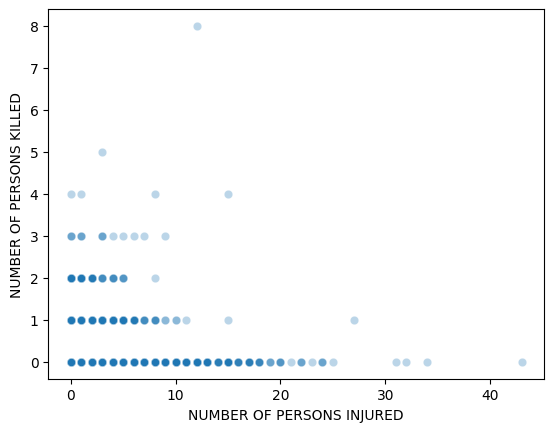

In [59]:
sns.scatterplot(data=copy_df,x="NUMBER OF PERSONS INJURED",y="NUMBER OF PERSONS KILLED",alpha=0.3)

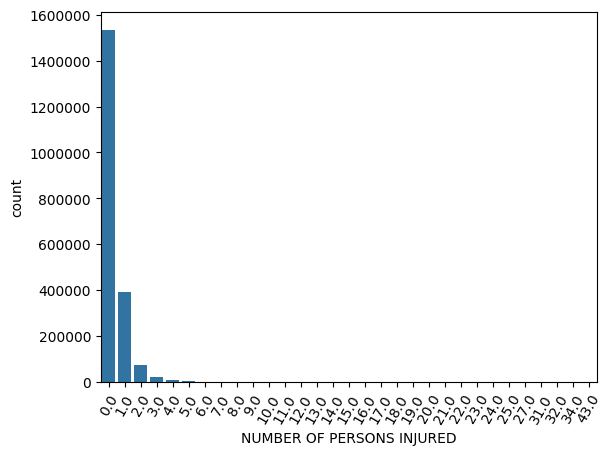

In [60]:
sns.countplot(data=copy_df,x='NUMBER OF PERSONS INJURED')
plt.xticks(rotation=60)
plt.ticklabel_format(style='plain', axis='y')

In [61]:
copy_df['VEHICLE TYPE CODE 1'].value_counts()

VEHICLE TYPE CODE 1
Sedan                                  616486
Station Wagon/Sport Utility Vehicle    480733
PASSENGER VEHICLE                      347166
SPORT UTILITY / STATION WAGON          150921
Taxi                                    54048
                                        ...  
FLAT  BED                                   1
Trac                                        1
CATAPILLAR                                  1
TRUCK VAN                                   1
PA                                          1
Name: count, Length: 1770, dtype: int64

In [62]:
"Unspecified" in copy_df['VEHICLE TYPE CODE 1'] 

False

In [63]:
(copy_df == 'Unspecified').sum()

CRASH DATE                            0
CRASH TIME                            0
BOROUGH                               0
ZIP CODE                              0
LATITUDE                              0
LONGITUDE                             0
NUMBER OF PERSONS INJURED             0
NUMBER OF PERSONS KILLED              0
NUMBER OF PEDESTRIANS INJURED         0
NUMBER OF PEDESTRIANS KILLED          0
NUMBER OF CYCLIST INJURED             0
NUMBER OF CYCLIST KILLED              0
NUMBER OF MOTORIST INJURED            0
NUMBER OF MOTORIST KILLED             0
CONTRIBUTING FACTOR VEHICLE 1    680443
COLLISION_ID                          0
VEHICLE TYPE CODE 1                   0
day_of_week                           0
is_weekend                            0
hour                                  0
injury_flag                           0
dtype: Int64

In [64]:
copy_df['VEHICLE TYPE CODE 1'].value_counts()

VEHICLE TYPE CODE 1
Sedan                                  616486
Station Wagon/Sport Utility Vehicle    480733
PASSENGER VEHICLE                      347166
SPORT UTILITY / STATION WAGON          150921
Taxi                                    54048
                                        ...  
FLAT  BED                                   1
Trac                                        1
CATAPILLAR                                  1
TRUCK VAN                                   1
PA                                          1
Name: count, Length: 1770, dtype: int64

In [65]:
copy_df['vehicle_clean'] = copy_df['VEHICLE TYPE CODE 1'].str.lower()

In [66]:
copy_df['vehicle_clean']

2                                        moped
9                                        sedan
10                                         NaN
12                                       sedan
13                                       sedan
                          ...                 
2246470                              ambulance
2246471    station wagon/sport utility vehicle
2246473    station wagon/sport utility vehicle
2246474    station wagon/sport utility vehicle
2246475    station wagon/sport utility vehicle
Name: vehicle_clean, Length: 2036431, dtype: object

In [67]:
def vehicle_category(x):

    if pd.isna(x):
        return 'Other'
    x = str(x).lower()
    if 'sedan' in x or 'passenger' in x or 'taxi' in x:
        return 'Car'
    elif 'sport utility' in x or 'suv' in x or 'station wagon' in x:
        return 'SUV'
    elif 'truck' in x or 'van' in x or 'pickup' in x:
        return 'Truck'
    else:
        return 'Other'

In [68]:
copy_df['vehicle_category'] = copy_df['vehicle_clean'].apply(vehicle_category)

In [69]:
copy_df['vehicle_category'].value_counts()

vehicle_category
Car      1084715
SUV       631676
Other     199991
Truck     120049
Name: count, dtype: int64

In [70]:
copy_df

,CRASH DATE,CRASH TIME,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,NUMBER OF PERSONS INJURED,NUMBER OF PERSONS KILLED,NUMBER OF PEDESTRIANS INJURED,NUMBER OF PEDESTRIANS KILLED,...,NUMBER OF MOTORIST KILLED,CONTRIBUTING FACTOR VEHICLE 1,COLLISION_ID,VEHICLE TYPE CODE 1,day_of_week,is_weekend,hour,injury_flag,vehicle_clean,vehicle_category
2,2023-11-01,1:29,BROOKLYN,11230,40.621790,-73.970024,1.0,0.0,0,0,...,0,Unspecified,4675373,Moped,2,0,1,1,moped,Other
9,2021-09-11,9:35,BROOKLYN,11208,40.667202,-73.866500,0.0,0.0,0,0,...,0,Unspecified,4456314,Sedan,5,1,9,0,sedan,Car
10,2021-12-14,8:13,BROOKLYN,11233,40.683304,-73.917274,0.0,0.0,0,0,...,0,Unspecified,4486609,NaN,1,0,8,0,NaN,Other
12,2021-12-14,17:05,UNKNOWN,0,40.709183,-73.956825,0.0,0.0,0,0,...,0,Passing Too Closely,4486555,Sedan,1,0,17,0,sedan,Car
13,2021-12-14,8:17,BRONX,10475,40.868160,-73.831480,2.0,0.0,0,0,...,0,Unspecified,4486660,Sedan,1,0,8,1,sedan,Car
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2246470,2026-03-03,12:40,BRONX,10453,40.854816,-73.911500,3.0,0.0,0,0,...,0,Driver Inattention/Distraction,4882931,Ambulance,1,0,12,1,ambulance,Other
2246471,2026-03-03,19:19,UNKNOWN,0,40.665520,-73.744670,0.0,0.0,0,0,...,0,Following Too Closely,4882837,Station Wagon/Sport Utility Vehicle,1,0,19,0,station wagon/sport utility vehicle,SUV
2246473,2026-02-28,23:50,MANHATTAN,10002,40.721798,-73.988240,0.0,0.0,0,0,...,0,Unspecified,4883299,Station Wagon/Sport Utility Vehicle,5,1,23,0,station wagon/sport utility vehicle,SUV
2246474,2026-03-03,22:15,UNKNOWN,0,40.834114,-73.863270,2.0,0.0,0,0,...,0,Other Vehicular,4883343,Station Wagon/Sport Utility Vehicle,1,0,22,1,station wagon/sport utility vehicle,SUV


In [71]:
copy_df = copy_df.drop(columns=['VEHICLE TYPE CODE 1','vehicle_clean'])

In [72]:
copy_df

,CRASH DATE,CRASH TIME,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,NUMBER OF PERSONS INJURED,NUMBER OF PERSONS KILLED,NUMBER OF PEDESTRIANS INJURED,NUMBER OF PEDESTRIANS KILLED,...,NUMBER OF CYCLIST KILLED,NUMBER OF MOTORIST INJURED,NUMBER OF MOTORIST KILLED,CONTRIBUTING FACTOR VEHICLE 1,COLLISION_ID,day_of_week,is_weekend,hour,injury_flag,vehicle_category
2,2023-11-01,1:29,BROOKLYN,11230,40.621790,-73.970024,1.0,0.0,0,0,...,0,1,0,Unspecified,4675373,2,0,1,1,Other
9,2021-09-11,9:35,BROOKLYN,11208,40.667202,-73.866500,0.0,0.0,0,0,...,0,0,0,Unspecified,4456314,5,1,9,0,Car
10,2021-12-14,8:13,BROOKLYN,11233,40.683304,-73.917274,0.0,0.0,0,0,...,0,0,0,Unspecified,4486609,1,0,8,0,Other
12,2021-12-14,17:05,UNKNOWN,0,40.709183,-73.956825,0.0,0.0,0,0,...,0,0,0,Passing Too Closely,4486555,1,0,17,0,Car
13,2021-12-14,8:17,BRONX,10475,40.868160,-73.831480,2.0,0.0,0,0,...,0,2,0,Unspecified,4486660,1,0,8,1,Car
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2246470,2026-03-03,12:40,BRONX,10453,40.854816,-73.911500,3.0,0.0,0,0,...,0,3,0,Driver Inattention/Distraction,4882931,1,0,12,1,Other
2246471,2026-03-03,19:19,UNKNOWN,0,40.665520,-73.744670,0.0,0.0,0,0,...,0,0,0,Following Too Closely,4882837,1,0,19,0,SUV
2246473,2026-02-28,23:50,MANHATTAN,10002,40.721798,-73.988240,0.0,0.0,0,0,...,0,0,0,Unspecified,4883299,5,1,23,0,SUV
2246474,2026-03-03,22:15,UNKNOWN,0,40.834114,-73.863270,2.0,0.0,0,0,...,0,2,0,Other Vehicular,4883343,1,0,22,1,SUV


In [73]:
copy_df.isna().sum()

CRASH DATE                        0
CRASH TIME                        0
BOROUGH                           0
ZIP CODE                          0
LATITUDE                          0
LONGITUDE                         0
NUMBER OF PERSONS INJURED        16
NUMBER OF PERSONS KILLED         28
NUMBER OF PEDESTRIANS INJURED     0
NUMBER OF PEDESTRIANS KILLED      0
NUMBER OF CYCLIST INJURED         0
NUMBER OF CYCLIST KILLED          0
NUMBER OF MOTORIST INJURED        0
NUMBER OF MOTORIST KILLED         0
CONTRIBUTING FACTOR VEHICLE 1     0
COLLISION_ID                      0
day_of_week                       0
is_weekend                        0
hour                              0
injury_flag                       0
vehicle_category                  0
dtype: int64

In [74]:
copy_df = copy_df.dropna(subset=['NUMBER OF PERSONS INJURED','NUMBER OF PERSONS KILLED'])

In [75]:
copy_df.value_counts()

CRASH DATE  CRASH TIME  BOROUGH    ZIP CODE  LATITUDE   LONGITUDE   NUMBER OF PERSONS INJURED  NUMBER OF PERSONS KILLED  NUMBER OF PEDESTRIANS INJURED  NUMBER OF PEDESTRIANS KILLED  NUMBER OF CYCLIST INJURED  NUMBER OF CYCLIST KILLED  NUMBER OF MOTORIST INJURED  NUMBER OF MOTORIST KILLED  CONTRIBUTING FACTOR VEHICLE 1   COLLISION_ID  day_of_week  is_weekend  hour  injury_flag  vehicle_category
2012-07-01  0:05        MANHATTAN  10036     40.762127  -73.997387  0.0                        0.0                       0                              0                             0                          0                         0                           0                          Driver Inattention/Distraction  37632         6            1           0     0            Car                 1
2019-06-21  9:30        MANHATTAN  10032     40.838060  -73.946650  0.0                        0.0                       0                              0                             0                  

In [76]:
copy_df.isna().sum()

CRASH DATE                       0
CRASH TIME                       0
BOROUGH                          0
ZIP CODE                         0
LATITUDE                         0
LONGITUDE                        0
NUMBER OF PERSONS INJURED        0
NUMBER OF PERSONS KILLED         0
NUMBER OF PEDESTRIANS INJURED    0
NUMBER OF PEDESTRIANS KILLED     0
NUMBER OF CYCLIST INJURED        0
NUMBER OF CYCLIST KILLED         0
NUMBER OF MOTORIST INJURED       0
NUMBER OF MOTORIST KILLED        0
CONTRIBUTING FACTOR VEHICLE 1    0
COLLISION_ID                     0
day_of_week                      0
is_weekend                       0
hour                             0
injury_flag                      0
vehicle_category                 0
dtype: int64

In [77]:
import pickle

In [78]:
copy_df.to_csv("clean_crash_data.csv", index=False)

In [79]:
copy_df.to_pickle("clean_crash_data.pkl")